# 00 · Construcción del Catálogo de Cúmulos
**Metodología:** §2.1 de Mayes+2026

A partir del catálogo de group IDs (generado por tu código de estado dinámico),
cargamos las propiedades necesarias de TNG-100 usando `illustris_python`
y construimos el catálogo base para el análisis ICL/BCG.

**Campos que se extraen:**
- M₂₀₀c, R₂₀₀c, posición del halo
- ID del BCG (GroupFirstSub)
- Tiempo desde el último merger mayor del BCG (árbol SubLink)

**Lo que NO se hace aquí:** estado dinámico (lo calcula tu código existente).
El estado dinámico puede añadirse al catálogo como columna adicional.


In [31]:
import sys, os, pickle
import numpy as np
import h5py
import matplotlib.pyplot as plt
from astropy.cosmology import FlatLambdaCDM

# Agregar el código original al path (solo lectura, no se modifica)
sys.path.insert(0, './original_shift_code')
import illustris_python as il
import params_icl as P                       # copia local de params para este análisis
import simulation_physical_improves as spi    # funciones de clasificación fossil/no-fossil

# Carpetas de salida para las figuras de este notebook
FIG_PDF = './figuras/00_catalogo/pdf'
FIG_PNG = './figuras/00_catalogo/png'
os.makedirs(FIG_PDF, exist_ok=True)
os.makedirs(FIG_PNG, exist_ok=True)

%matplotlib inline
plt.rcParams.update({'figure.dpi': 110, 'font.size': 12,
                     'axes.spines.top': False, 'axes.spines.right': False})

cosmo = FlatLambdaCDM(H0=67.74, Om0=0.3089)
print(f"basePath : {P.basePath}")
print(f"Snapshot : {P.SNAP}")
print(f"h = {P.h},  UL = {P.UL:.4f},  UM = {P.UM:.3e}")

basePath : /home/tnguser/sims.TNG/TNG100-1/output/
Snapshot : 99
h = 0.6774,  UL = 1.4762,  UM = 1.476e+10


## 1 · Cargar catálogos de halos/subhalos y clasificar fossil/no-fossil

- `mary_haloshift_z0.pkl` → catálogo de halos (M200c por encima del umbral de cúmulo): **se usa directamente como catálogo de halos**, sin volver a consultar `il.groupcat`.
- `mary_subhaloshift_z0.pkl` → catálogo de subhalos asociados: **se usa para determinar fossil/no-fossil** (criterio de Jones+2003: Δm_r ≥ `P.GAP_THRESHOLD` entre el BCG y la siguiente galaxia más brillante dentro de `P.R_FRAC_FOSSIL`·R200c).

### Sobre la indexación (`GroupNumber` / `SubhaloNumber`)

Estos pickles fueron generados por `original_shift_code/Catalogue.py::TNG2PROPnum`, que les
añade el número de snapshot como preámbulo: `valor_guardado = snap*1e10 + índice`
(snap=99 → preámbulo `990000000...`). Para recuperar el índice real basta restar
`P.SNAP * 1e10` (el snapshot es editable en `params_icl.py`, así que esta resta también
lo es automáticamente).

**Pero ojo:** `GroupNumber` y `SubhaloNumber` en sí NO son el índice absoluto de TNG —
son una renumeración local secuencial (0, 1, 2, ... según la posición en el pickle).
Solo `GroupFirstSub` y `SubhaloGrNr` conservan los IDs absolutos originales de TNG
(subfind ID / FoF index), simplemente desplazados por el mismo preámbulo.

Como la selección de halos (`Halos_limits` en `original_shift_code/params.py`) no es un
corte 100% contiguo desde el grupo más masivo, el índice de **posición local** dentro del
pickle (0..181) **no coincide** con el índice de grupo absoluto de TNG más allá de los
primeros ~53 halos. Por eso recuperamos el índice absoluto real haciendo *match* exacto de
posición (`GroupPos` del halo == `SubhaloPos` de su subhalo central), en vez de asumir que
ambos índices coinciden.

In [32]:
# ── Cargar los catálogos generados por el código de shift (TNG2PROPnum) ───
with open(P.CATALOG_PKL, 'rb') as f:
    halos_shift = pickle.load(f)
with open(P.CATALOG_SUBHALOSHIFT_PKL, 'rb') as f:
    subhalos_shift = pickle.load(f)

print(f"Halos (mary_haloshift_z0)       : {halos_shift['count']} halos")
print(f"Subhalos (mary_subhaloshift_z0) : {subhalos_shift['count']} subhalos")

# ── Quitar el preámbulo snap*1e10 (editable vía P.SNAP) ───────────────────
offset = P.SNAP * int(1e10)

GroupNumber_raw    = halos_shift['GroupNumber']     - offset   # renumeración local (0..N-1), NO el índice TNG
GroupFirstSub_raw  = halos_shift['GroupFirstSub']   - offset   # subfind ID absoluto del BCG (sí es real)
SubhaloNumber_raw  = subhalos_shift['SubhaloNumber']- offset   # renumeración local (0..M-1), NO el índice TNG
SubhaloGrNr_raw    = subhalos_shift['SubhaloGrNr']  - offset   # FoF index absoluto de cada subhalo (sí es real)

n_halos = int(halos_shift['count'])

print(f"\nGroupNumber  (preámbulo quitado) : {GroupNumber_raw[:5]} ... {GroupNumber_raw[-3:]}  (renumeración local)")
print(f"GroupFirstSub(preámbulo quitado) : {GroupFirstSub_raw[:5]} ...  (subfind ID absoluto, sí útil)")
print(f"SubhaloGrNr  (preámbulo quitado) : {SubhaloGrNr_raw[:5]} ...   (FoF index absoluto, sí útil)")

Halos (mary_haloshift_z0)       : 182 halos
Subhalos (mary_subhaloshift_z0) : 5225 subhalos

GroupNumber  (preámbulo quitado) : [0 1 2 3 4] ... [213 214 223]  (renumeración local)
GroupFirstSub(preámbulo quitado) : [    0 17185 31342 41582 52618] ...  (subfind ID absoluto, sí útil)
SubhaloGrNr  (preámbulo quitado) : [0 0 0 0 0] ...   (FoF index absoluto, sí útil)


In [33]:
# ── Recuperar el índice de grupo TNG absoluto por coincidencia de posición ──
# GroupPos del halo == SubhaloPos de su subhalo central (mismo dato, sin
# recomputar), así que el match debe ser exacto (o casi). Esto también nos da
# de regalo la fila del BCG dentro de subhalos_shift, sin heurísticas.

M200_h     = halos_shift['Group_M_Crit200']     # 1e10 M☉/h
R200_h     = halos_shift['Group_R_Crit200']      # ckpc/h
GroupPos_h = halos_shift['GroupPos']             # ckpc/h
pos_sub    = subhalos_shift['SubhaloPos']        # ckpc/h

raw_mtype = subhalos_shift['SubhaloMassType']
mtype_sub = raw_mtype.reshape(-1, 6) if raw_mtype.ndim == 1 else raw_mtype
mag_r     = subhalos_shift['SubhaloStellarPhotometrics'][:, 5]     # banda r
mstar_sub = np.log10(mtype_sub[:, 4] / P.h + 1e-30) + 10           # log M☉

true_abs_group = np.full(n_halos, -1, dtype=np.int64)   # índice FoF absoluto real de cada halo k
bcg_row        = np.full(n_halos, -1, dtype=np.int64)   # fila del BCG en subhalos_shift

TOL = 1e-2   # ckpc/h — tolerancia del match de posición
for k in range(n_halos):
    diffs = np.abs(pos_sub - GroupPos_h[k]).sum(axis=1)
    row   = np.argmin(diffs)
    if diffs[row] < TOL:
        bcg_row[k]        = row
        true_abs_group[k] = SubhaloGrNr_raw[row]

n_unmatched = (true_abs_group < 0).sum()
n_diff_idx  = (true_abs_group != np.arange(n_halos)).sum()
print(f"Halos sin match de posición          : {n_unmatched}/{n_halos}")
print(f"Halos donde índice local != absoluto : {n_diff_idx}/{n_halos}  "
      f"(confirma que NO se puede asumir índice local == índice TNG)")

Halos sin match de posición          : 0/182
Halos donde índice local != absoluto : 129/182  (confirma que NO se puede asumir índice local == índice TNG)


In [34]:
# ── Clasificación fossil / no-fossil (criterio de Jones+2003) ─────────────
# Un cúmulo es "fossil" si Δm_r ≥ P.GAP_THRESHOLD entre el BCG y la siguiente
# galaxia más brillante dentro de P.R_FRAC_FOSSIL * R200c.
# Usamos true_abs_group[k] (índice FoF absoluto real) como identificador,
# para que group_idx sea directamente compatible con il.snapshot/il.sublink.

F_lists  = ([], [], [], [], [], [])   # group, Δmag, distancias, M200, R200, sats
NF_lists = ([], [], [], [], [], [])
iso_groups, iso_mass, iso_radius = [], [], []
bcg_row_by_absgroup = {}   # índice FoF absoluto → fila del BCG en subhalos_shift

for k in range(n_halos):
    if true_abs_group[k] < 0:
        print(f"⚠ Halo local {k}: no se encontró el BCG por posición, se omite")
        continue

    abs_group   = true_abs_group[k]
    central_row = bcg_row[k]
    r200_halo   = R200_h[k]
    m200_halo   = M200_h[k]
    central_pos = GroupPos_h[k]

    gals = np.where((SubhaloGrNr_raw == abs_group) & (mstar_sub >= P.MASS_CUT_LOG10))[0]
    if central_row not in gals:
        gals = np.append(gals, central_row)
    bcg_row_by_absgroup[abs_group] = central_row

    xc = spi.Distance_1D(pos_sub[gals, 0], central_pos[0], P.L_BOX)
    yc = spi.Distance_1D(pos_sub[gals, 1], central_pos[1], P.L_BOX)
    zc = spi.Distance_1D(pos_sub[gals, 2], central_pos[2], P.L_BOX)
    normpos = np.sqrt(xc**2 + yc**2 + zc**2) / r200_halo
    normpos[gals == central_row] = 0.0   # forzar BCG a distancia 0 (evita ruido numérico)

    mags_all    = mag_r[gals]
    central_mag = mags_all[gals == central_row]

    classified = spi.classify_fossil(abs_group, mags_all, central_mag, normpos, gals,
                                      m200_halo, r200_halo, F_lists, NF_lists,
                                      r_frac=P.R_FRAC_FOSSIL, gap_threshold=P.GAP_THRESHOLD)
    if not classified:
        iso_groups.append(abs_group); iso_mass.append(m200_halo); iso_radius.append(r200_halo)

fossil_idx    = np.array(F_lists[0],  dtype=int)
nonfossil_idx = np.array(NF_lists[0], dtype=int)
group_idx     = np.unique(np.concatenate([fossil_idx, nonfossil_idx]))   # índice FoF absoluto real de TNG

abs_to_local  = {true_abs_group[k]: k for k in range(n_halos) if true_abs_group[k] >= 0}
local_pos     = np.array([abs_to_local[g] for g in group_idx])           # posición en halos_shift
bcg_sub_local = np.array([bcg_row_by_absgroup[g] for g in group_idx])    # posición en subhalos_shift

n_cl = len(group_idx)
print(f"\nFossil      ({P.R_FRAC_FOSSIL:g}*R200) : {len(fossil_idx)} cúmulos")
print(f"No-fossil   ({P.R_FRAC_FOSSIL:g}*R200) : {len(nonfossil_idx)} cúmulos")
print(f"Sin satélites dentro de {P.R_FRAC_FOSSIL:g}*R200 : {len(iso_groups)} cúmulos (excluidos)")
print(f"Total a analizar (group_idx, índices TNG absolutos): {n_cl} cúmulos (únicos)")

3.0944900512695312
Group 0 classified as fossil with gap 3.09 and R/R200 [0.23104057 0.2516273  0.27025825 0.1476838  0.28323776 0.38950428
 0.10478711 0.3322185  0.26542953 0.31814736 0.1817361  0.35955262
 0.09023058 0.3868526  0.40244067 0.18854342 0.27468467 0.03182445
 0.46181715 0.08406492 0.26396084 0.47370967 0.2784363  0.39337152
 0.2296766  0.36882085 0.08460205 0.13974595 0.32640186 0.30208698
 0.25865945 0.21353161 0.08151355 0.15491483 0.39200974 0.2740041
 0.46118924 0.1880704  0.05994023 0.22999907]
1.4233970642089844
Group 1 classified as non-fossil with gap 1.42 and R/R200 [0.34477258 0.48401576 0.2283023  0.3587478  0.42946666 0.43552676
 0.36434418 0.237215   0.00401617 0.42362046 0.25370678 0.42690083
 0.33653823 0.19043112 0.14223444 0.3581571  0.2798194  0.33553407
 0.07570504 0.01954804 0.45790642 0.27660552 0.3118317  0.43582606
 0.26351035 0.4623331  0.17267436 0.24640256 0.06658264 0.26290846
 0.46155217 0.06745172]
1.9652290344238281
Group 2 classified as non

## 2 · Propiedades de halo (directamente de `mary_haloshift_z0`)

No es necesario volver a llamar a `il.groupcat.loadHalos` para el catálogo completo:
`halos_shift` ya contiene las propiedades de estos cúmulos.

In [35]:
# Header de TNG (solo metadata: BoxSize, Redshift, Time)
Header = il.groupcat.loadHeader(P.basePath, P.SNAP)
print("BoxSize (ckpc/h):", Header['BoxSize'])
print("Redshift        :", Header['Redshift'])
print("Time (a)        :", Header['Time'])

BoxSize (ckpc/h): 75000.0
Redshift        : 2.220446049250313e-16
Time (a)        : 0.9999999999999998


In [36]:
# Extraer propiedades de halo directamente de halos_shift (sin re-consultar TNG)
# Importante: indexar por local_pos (posición en el pickle), NO por group_idx
# (que ahora es el índice TNG absoluto, distinto de la posición local).
M200c_raw = M200_h[local_pos]                          # 1e10 M☉/h
R200c_raw = R200_h[local_pos]                          # ckpc/h
GroupPos  = GroupPos_h[local_pos] * P.UL               # kpc físicos
GroupCM   = halos_shift['GroupCM'][local_pos] * P.UL   # kpc físicos
first_sub = GroupFirstSub_raw[local_pos]                # subfind ID absoluto del BCG

# Convertir a unidades físicas
M200c = M200c_raw * P.UM     # M☉ (lineal)
R200c = R200c_raw * P.UL     # kpc físicos

print(f"N cúmulos         : {n_cl}")
print(f"log M200c (M☉)    : {np.log10(M200c.min()):.2f} – {np.log10(M200c.max()):.2f}")
print(f"R200c [kpc]       : {R200c.min():.0f} – {R200c.max():.0f}")
print(f"Primeros group_idx (abs. TNG)  : {group_idx[:5]}")
print(f"Primeros GroupFirstSub         : {first_sub[:5]}")

N cúmulos         : 166
log M200c (M☉)    : 13.01 – 14.58
R200c [kpc]       : 457 – 1529
Primeros group_idx (abs. TNG)  : [0 1 2 3 4]
Primeros GroupFirstSub         : [    0 17185 31342 41582 52618]


## 3 · Posición y masa estelar del BCG (directamente de `mary_subhaloshift_z0`)

`bcg_sub_local` ya identifica la posición de cada BCG dentro de `subhalos_shift`
(calculado durante la clasificación fossil en la sección 1).

In [37]:
# Posición y masa estelar del BCG, leídas de mary_subhaloshift_z0
bcg_pos    = pos_sub[bcg_sub_local] * P.UL                 # kpc físicos
bcg_M_star = mtype_sub[bcg_sub_local, 4] * P.UM             # M☉ (lineal)

print("Posición BCG (primeros 3):")
for i in range(min(3, n_cl)):
    print(f"  Cúmulo (group_idx={group_idx[i]}): pos = {bcg_pos[i]}")
print(f"\nMasa estelar BCG: {np.log10(bcg_M_star.min()):.2f} – {np.log10(bcg_M_star.max()):.2f} log M☉")

Posición BCG (primeros 3):
  Cúmulo (group_idx=0): pos = [ 1253.4565 38864.77   27025.293 ]
  Cúmulo (group_idx=1): pos = [29163.488 70202.195 72218.24 ]
  Cúmulo (group_idx=2): pos = [16091.279 75078.11  70254.555]

Masa estelar BCG: 10.99 – 12.57 log M☉


## 4 · Tiempo desde el último merger mayor del BCG

Usamos el árbol SubLink de TNG para trazar el Main Progenitor Branch (MPB) del BCG
y encontrar el último evento de fusión con razón de masa estelar ≥ 1/5.

Referencia: Mayes+2026 §2 + Rodríguez-Gómez+2015


In [38]:
def time_since_last_major_merger(bcg_id, basePath, snap, cosmo,
                                    mass_ratio_min=0.2):
    """
    Traza el árbol MPB del BCG y encuentra el último merger mayor.

    Parámetros
    ----------
    bcg_id        : int, índice del subhalo BCG en snap
    mass_ratio_min: float, razón mínima de masa estelar (defecto 1/5)

    Devuelve
    --------
    t_lookback : float, tiempo de lookback en Gyr desde z=0 hasta el merger.
                 NaN si no hay merger mayor registrado.
    """
    fields = ['SnapNum', 'SubhaloMassType', 'SubhaloID',
              'NextProgenitorID', 'FirstProgenitorID', 'MainLeafProgenitorID']
    try:
        tree = il.sublink.loadTree(basePath, snap, bcg_id, fields=fields,
                                    onlyMPB=False)
    except Exception as e:
        return np.nan

    if tree is None or 'SnapNum' not in tree:
        return np.nan

    snap_arr   = tree['SnapNum']
    mass_arr   = tree['SubhaloMassType'][:, 4]   # masa estelar (tipo 4)

    # Masa del progenitor principal en cada snapshot
    # Los snapshots están ordenados de z=0 hacia atrás en el MPB
    # Para detectar mergers: buscar el snap donde la masa del 2do progenitor
    # es significativa respecto a la del progenitor principal.
    # Usando la masa del PROG2: M_main[snap] - M_main[snap+1] (masa que se sumó)
    # Aproximación: Δm = masa sumada en cada paso del árbol
    # La masa del 2do progenitor = masa del subtree que se une = Δm

    # Identificamos mergers como: M_main(t-1) salta más que factor respecto a M_main(t)
    # (el MPB tiene masa creciente hacia z=0, decrece hacia atrás)
    # Un merger mayor ocurre cuando la masa cae significativamente hacia atrás:
    # ratio = M_main[i+1] / M_main[i] < (1 - mass_ratio_min / (1 + mass_ratio_min))
    t_last = np.nan
    for i in range(len(snap_arr) - 1):
        m_now  = mass_arr[i]
        m_prev = mass_arr[i + 1]
        if m_now <= 0 or m_prev <= 0:
            continue
        # Masa del 2do progenitor ≈ masa ganada en este paso
        m2 = m_now - m_prev
        if m2 <= 0:
            continue
        ratio = m2 / m_prev   # ≈ M2/M1 en el momento del merger
        if ratio >= mass_ratio_min:
            snap_merger = snap_arr[i]
            z_merger    = il.groupcat.loadHeader(basePath, int(snap_merger))['Redshift']
            t_last      = cosmo.lookback_time(z_merger).value   # Gyr
            break   # primer (más reciente) merger mayor encontrado

    return t_last

print("Calculando tiempo desde el último merger mayor...")
t_last_merger = np.full(n_cl, np.nan)
for i, sub_id in enumerate(first_sub):
    t_last_merger[i] = time_since_last_major_merger(
        int(sub_id), P.basePath, P.SNAP, cosmo)
    if (i+1) % 10 == 0:
        print(f"  {i+1}/{n_cl}  t_med = {np.nanmedian(t_last_merger[:i+1]):.2f} Gyr", end="\r")
print(f"\nMerger mayor encontrado en {np.isfinite(t_last_merger).sum()}/{n_cl} cúmulos")


Calculando tiempo desde el último merger mayor...
  160/166  t_med = 7.92 Gyr
Merger mayor encontrado en 166/166 cúmulos


## 5 · Guardar el catálogo

In [39]:
# Guardar como HDF5 para uso en los siguientes notebooks
with h5py.File(P.CATALOG_OUT, 'w') as f:
    f.attrs['basePath']    = P.basePath
    f.attrs['snap']        = P.SNAP
    f.attrs['n_clusters']  = n_cl

    f.create_dataset('group_idx',     data=group_idx)    # índice FoF en TNG
    f.create_dataset('M200c_Msun',    data=M200c)        # M☉
    f.create_dataset('R200c_kpc',     data=R200c)        # kpc físicos
    f.create_dataset('GroupPos_kpc',  data=GroupPos)     # kpc físicos (3D)
    f.create_dataset('GroupCM_kpc',   data=GroupCM)      # kpc físicos (3D)
    f.create_dataset('bcg_sub_idx',   data=first_sub)    # índice subhalo BCG
    f.create_dataset('bcg_pos_kpc',   data=bcg_pos)      # kpc físicos (3D)
    f.create_dataset('bcg_Mstar_Msun',data=bcg_M_star)   # M☉
    f.create_dataset('t_last_merger_Gyr', data=t_last_merger)  # Gyr

print(f"Catálogo guardado en: {P.CATALOG_OUT}")
print(f"  N cúmulos          : {n_cl}")
print(f"  log M200c [M☉]     : {np.log10(M200c.min()):.2f} – {np.log10(M200c.max()):.2f}")


Catálogo guardado en: ./catalogo_icl.hdf5
  N cúmulos          : 166
  log M200c [M☉]     : 13.01 – 14.58


## 6 · Visualización rápida del catálogo

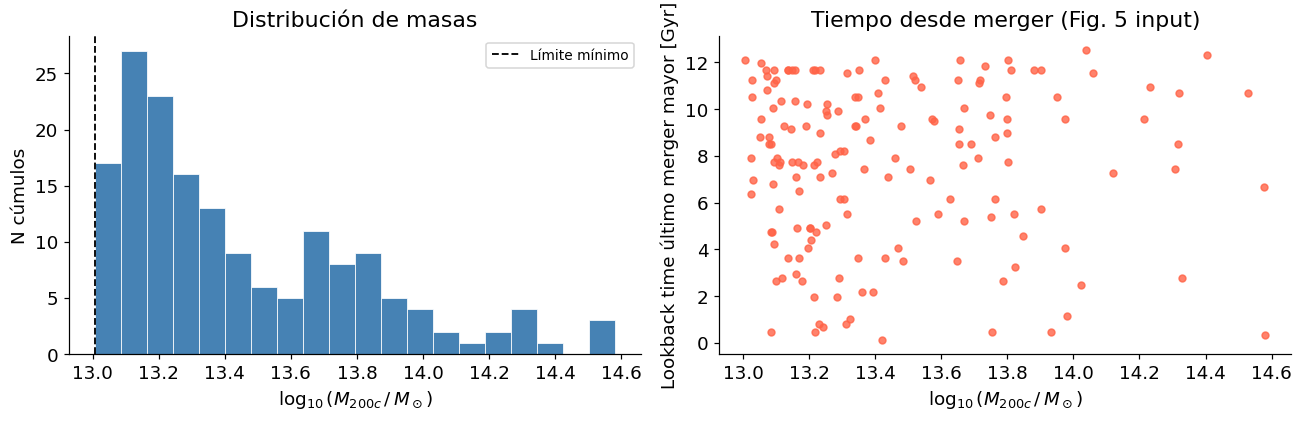

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.hist(np.log10(M200c), bins=20, color='steelblue', edgecolor='white', lw=0.5)
ax.axvline(np.log10(M200c.min()), ls='--', color='k', lw=1.2, label='Límite mínimo')
ax.set_xlabel(r'$\log_{10}(M_{200c}\,/\,M_\odot)$')
ax.set_ylabel('N cúmulos')
ax.set_title('Distribución de masas')
ax.legend(fontsize=9)

ax = axes[1]
valid = np.isfinite(t_last_merger)
ax.scatter(np.log10(M200c[valid]), t_last_merger[valid],
           s=20, alpha=0.8, color='tomato')
ax.set_xlabel(r'$\log_{10}(M_{200c}\,/\,M_\odot)$')
ax.set_ylabel('Lookback time último merger mayor [Gyr]')
ax.set_title('Tiempo desde merger (Fig. 5 input)')

plt.tight_layout()
plt.savefig(f'{FIG_PDF}/fig_catalogo.pdf', bbox_inches='tight')
plt.savefig(f'{FIG_PNG}/fig_catalogo.png', bbox_inches='tight', dpi=150)
plt.show()

# Añadir estado dinámico al catálogo si ya lo tienes calculado:
# with h5py.File(P.CATALOG_OUT, 'a') as f:
#     f.create_dataset('dyn_state', data=mi_array_dyn_state)
#     # 0=relajado, 1=intermedio, 2=perturbado